# Kalibrasi Prediksi Agregat Bulanan - Model Spatial Click M>=5
Notebook ini fokus untuk memperbaiki bias over-prediction pada agregat bulanan (actual vs pred_expected_total).

Langkah utama:
1. Load hasil prediksi test dari artifact model M>=5
2. Hitung baseline error agregat bulanan
3. Fit kalibrator pada subset bulan kalibrasi
4. Evaluasi di holdout month
5. Simpan parameter kalibrasi untuk dipakai di aplikasi/inferensi

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path(r"D:\\Projects\\bencana_dicoding_app")
ARTIFACT_DIR = PROJECT_ROOT / 'timeseries_triwulan' / 'artifacts' / 'model_spatial_click_m5'
PRED_PATH = ARTIFACT_DIR / 'predictions_test_spatial.csv'
METRICS_PATH = ARTIFACT_DIR / 'metrics_spatial.csv'

if not PRED_PATH.exists():
    raise FileNotFoundError(f'File tidak ditemukan: {PRED_PATH}')

pred_df = pd.read_csv(PRED_PATH)
pred_df['month'] = pd.to_datetime(pred_df['month'])

print('Artifact dir:', ARTIFACT_DIR)
print('Prediction rows:', len(pred_df))
print('Month range:', pred_df['month'].min(), '->', pred_df['month'].max())

Artifact dir: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m5
Prediction rows: 7920
Month range: 2024-10-01 00:00:00 -> 2025-09-01 00:00:00


In [2]:
monthly = (
    pred_df.groupby('month', as_index=False)
    .agg(
        actual_total=('count_m5', 'sum'),
        pred_expected_total=('pred_expected_count', 'sum')
    )
    .sort_values('month')
    .reset_index(drop=True)
)

def summarize_errors(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mae = float(np.mean(np.abs(actual - pred)))
    rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
    mape = float(np.mean(np.abs((actual - pred) / np.maximum(actual, 1e-6))) * 100.0)
    smape = float(
        np.mean(
            2.0 * np.abs(actual - pred) / np.maximum(np.abs(actual) + np.abs(pred), 1e-6)
        )
        * 100.0
    )
    bias = float(np.mean(pred - actual))
    return {'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape, 'sMAPE_pct': smape, 'Bias_pred_minus_actual': bias}

baseline_summary = summarize_errors(monthly['actual_total'], monthly['pred_expected_total'])
display(monthly)
display(pd.DataFrame([baseline_summary]))

,month,actual_total,pred_expected_total
0,2024-10-01,13.0,19.002588
1,2024-11-01,5.0,20.785436
2,2024-12-01,7.0,22.122964
3,2025-01-01,6.0,19.133274
4,2025-02-01,13.0,17.893739
5,2025-03-01,8.0,19.445708
6,2025-04-01,5.0,19.871044
7,2025-05-01,7.0,18.679687
8,2025-06-01,1.0,15.461907
9,2025-07-01,10.0,19.141883


,MAE,RMSE,MAPE_pct,sMAPE_pct,Bias_pred_minus_actual
0,11.314639,11.905448,280.222037,91.682858,11.314639


In [3]:
N_CAL_MONTHS = 8

if len(monthly) <= N_CAL_MONTHS:
    raise ValueError('Jumlah bulan test terlalu sedikit untuk split calibration-holdout.')

cal_df = monthly.iloc[:N_CAL_MONTHS].copy()
holdout_df = monthly.iloc[N_CAL_MONTHS:].copy()

x_cal = cal_df['pred_expected_total'].to_numpy(dtype=float)
y_cal = cal_df['actual_total'].to_numpy(dtype=float)
x_hold = holdout_df['pred_expected_total'].to_numpy(dtype=float)
y_hold = holdout_df['actual_total'].to_numpy(dtype=float)

# Calibrator 1: multiplicative scaling (global ratio)
alpha = float(y_cal.sum() / max(x_cal.sum(), 1e-9))

# Calibrator 2: affine scaling y = a + b*x, clipped >= 0
b, a = np.polyfit(x_cal, y_cal, deg=1)
a = float(a)
b = float(b)

holdout_df['pred_scaled_ratio'] = holdout_df['pred_expected_total'] * alpha
holdout_df['pred_scaled_affine'] = np.clip(a + b * holdout_df['pred_expected_total'], 0.0, None)

summary_holdout = pd.DataFrame([
    {'model': 'baseline', **summarize_errors(y_hold, x_hold)},
    {'model': 'ratio_scaled', **summarize_errors(y_hold, holdout_df['pred_scaled_ratio'])},
    {'model': 'affine_scaled', **summarize_errors(y_hold, holdout_df['pred_scaled_affine'])},
])

print(f'Calibration months: {cal_df["month"].min().date()} -> {cal_df["month"].max().date()}')
print(f'Holdout months: {holdout_df["month"].min().date()} -> {holdout_df["month"].max().date()}')
print(f'alpha (ratio scaling) = {alpha:.6f}')
print(f'affine params: a = {a:.6f}, b = {b:.6f}')
display(holdout_df)
display(summary_holdout.sort_values('MAE'))

Calibration months: 2024-10-01 -> 2025-05-01
Holdout months: 2025-06-01 -> 2025-09-01
alpha (ratio scaling) = 0.407814
affine params: a = 34.625521, b = -1.357281


,month,actual_total,pred_expected_total,pred_scaled_ratio,pred_scaled_affine
8,2025-06-01,1.0,15.461907,6.305576,13.639365
9,2025-07-01,10.0,19.141883,7.806320,8.644602
10,2025-08-01,11.0,17.140056,6.989948,11.361645
11,2025-09-01,4.0,17.097377,6.972543,11.419573


,model,MAE,RMSE,MAPE_pct,sMAPE_pct,Bias_pred_minus_actual
1,ratio_scaled,3.620463,3.803876,165.815749,67.162286,0.518597
2,affine_scaled,5.443995,7.361581,366.566863,71.671501,4.766296
0,baseline,10.710306,11.202258,480.215666,101.560609,10.710306


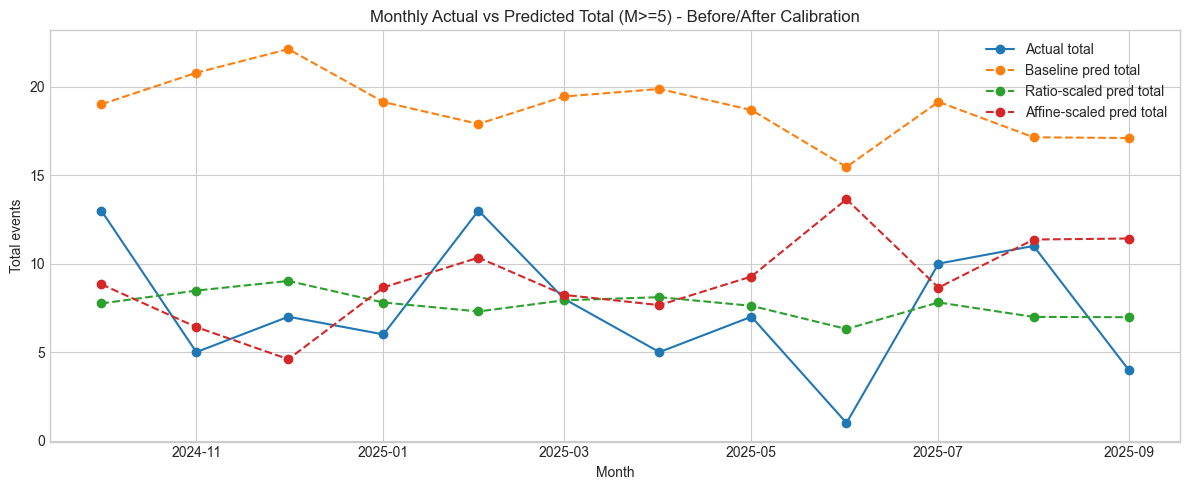

In [4]:
monthly['pred_scaled_ratio'] = monthly['pred_expected_total'] * alpha
monthly['pred_scaled_affine'] = np.clip(a + b * monthly['pred_expected_total'], 0.0, None)

plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['actual_total'], marker='o', label='Actual total')
plt.plot(monthly['month'], monthly['pred_expected_total'], marker='o', linestyle='--', label='Baseline pred total')
plt.plot(monthly['month'], monthly['pred_scaled_ratio'], marker='o', linestyle='--', label='Ratio-scaled pred total')
plt.plot(monthly['month'], monthly['pred_scaled_affine'], marker='o', linestyle='--', label='Affine-scaled pred total')
plt.title('Monthly Actual vs Predicted Total (M>=5) - Before/After Calibration')
plt.xlabel('Month')
plt.ylabel('Total events')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
calibration_params = {
    'target': 'monthly_total_m5',
    'calibration_months': [str(cal_df['month'].min().date()), str(cal_df['month'].max().date())],
    'holdout_months': [str(holdout_df['month'].min().date()), str(holdout_df['month'].max().date())],
    'ratio_scale_alpha': alpha,
    'affine_intercept_a': a,
    'affine_slope_b': b
}

params_path = ARTIFACT_DIR / 'calibration_params_m5.json'
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(calibration_params, f, indent=2)

pred_cal_path = ARTIFACT_DIR / 'predictions_test_spatial_with_calibration.csv'
pred_df['pred_expected_count_ratio_scaled'] = pred_df['pred_expected_count'] * alpha
pred_df['pred_expected_count_affine_scaled'] = np.clip(a + b * pred_df['pred_expected_count'], 0.0, None)
pred_df.to_csv(pred_cal_path, index=False)

print('Saved calibration params:', params_path)
print('Saved calibrated prediction table:', pred_cal_path)
display(pd.DataFrame([calibration_params]))

Saved calibration params: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m5\calibration_params_m5.json
Saved calibrated prediction table: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m5\predictions_test_spatial_with_calibration.csv


,target,calibration_months,holdout_months,ratio_scale_alpha,affine_intercept_a,affine_slope_b
0,monthly_total_m5,"[2024-10-01, 2025-05-01]","[2025-06-01, 2025-09-01]",0.407814,34.625521,-1.357281


## Catatan Penting
- Kalibrasi di notebook ini bersifat **post-hoc** pada output model yang sudah ada.
- Untuk penggunaan produksi, pakai parameter dari file `calibration_params_m5.json` ke output prediksi sebelum ditampilkan sebagai total bulanan.
- Jika data baru masuk, kalibrasi sebaiknya di-fit ulang secara berkala.